# 📈 Time Series with Pandas
### A Step-by-Step Lesson for Beginners

---
**Topics we will cover:**
1. What is a Time Series? + Loading data
2. Date formats & common pitfalls
3. DatetimeIndex & sorting
4. Date slicing
5. Date ranges & frequencies
6. Reindexing with a date range
7. Shifting
8. Resampling — Downsampling
9. Resampling — Upsampling + ffill / bfill
10. Interpolation
11. Rolling windows
12. Expanding windows
13. Aggregation with .agg()

## 🔧 Step 0 — Install required libraries
Run this cell once. You can skip it if these are already installed.

In [ ]:
!pip install pandas numpy matplotlib

## 📦 Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
pd.options.display.float_format = '{:,.2f}'.format

print('Libraries loaded successfully!')

Libraries loaded successfully!


---
# 📌 Topic 1 — What is a Time Series? + Loading Data

A **time series** is data collected or recorded at regular time intervals.

Examples:
- Stock prices every day
- Temperature every hour
- Website visits every minute

In pandas, we use a **DatetimeIndex** — the row labels are dates instead of numbers.

**Key tips when loading:**
- `index_col='Date'` → makes the Date column the row label
- `parse_dates=True` → converts text dates into real datetime objects

In [3]:
df = pd.read_csv('data/stocks.csv', index_col='Date', parse_dates=True)

print('Shape:', df.shape)
print('Index type:', type(df.index))
df.head()

Shape: (60, 6)
Index type: <class 'pandas.DatetimeIndex'>


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-01-02,"1,339.39","1,368.68","1,333.37","1,360.66","1,360.66",1450000
2020-01-03,"1,355.00","1,360.00","1,320.00","1,347.83","1,347.83",1380000
2020-01-06,"1,344.00","1,394.48","1,340.00","1,394.48","1,394.48",1620000
2020-01-07,"1,393.00","1,400.00","1,375.00","1,389.52","1,389.52",1390000
2020-01-08,"1,380.00","1,410.00","1,375.00","1,404.50","1,404.50",1510000


In [4]:
df.tail()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-03-23,"1,003.00","1,053.00",996.00,"1,054.68","1,054.68",4430000
2020-03-24,"1,100.00","1,142.00","1,083.00","1,139.22","1,139.22",3970000
2020-03-25,"1,120.00","1,152.00","1,092.00","1,102.61","1,102.61",3560000
2020-03-26,"1,175.00","1,215.00","1,163.00","1,209.77","1,209.77",3240000
2020-03-27,"1,179.00","1,194.00","1,147.00","1,162.81","1,162.81",3120000


---
# 📌 Topic 2 — Date Formats & Common Pitfalls

⚠️ Very common beginner mistake!

These look similar but mean different things:
- `2020-03-01` → March 1st
- `2020-01-03` → January 3rd

Always check your CSV format before slicing.

In [5]:
print('First date:', df.index[0])
print('Last date: ', df.index[-1])
print('Index dtype:', df.index.dtype)

First date: 2020-01-02 00:00:00
Last date:  2020-03-27 00:00:00
Index dtype: datetime64[us]


In [6]:
# Without parse_dates — dates stay as plain text strings
df_wrong = pd.read_csv('data/stocks.csv', index_col='Date')

print('Without parse_dates:', df_wrong.index.dtype)
print('With    parse_dates:', df.index.dtype)
# Text dates cannot be sliced, shifted, or resampled properly!

Without parse_dates: str
With    parse_dates: datetime64[us]


---
# 📌 Topic 3 — DatetimeIndex & Sorting

Before slicing, **always sort your index first**.

- Ascending → earliest date at the top
- Descending → latest date at the top

⚠️ In newer pandas, slicing a descending index with ascending dates raises a **KeyError** — not just an empty DataFrame!

The safest rule: **always sort ascending, then slice**. If you ever need to work with a descending index, use boolean masking with `.loc[]` instead.

In [7]:
df = df.sort_index(ascending=True)

print('First row:', df.index[0])
print('Last row: ', df.index[-1])

First row: 2020-01-02 00:00:00
Last row:  2020-03-27 00:00:00


In [8]:
# Pitfall demo — newer pandas RAISES AN ERROR if you slice a descending index
# with ascending date order. The safest habit: always sort ascending first,
# then slice. That's what we do for the rest of this notebook.

df_desc = df.sort_index(ascending=False)

# Safe way to filter on a descending index → use boolean masking with .loc[]
jan_mask = (df_desc.index >= '2020-01-01') & (df_desc.index <= '2020-01-31')
jan_rows = df_desc.loc[jan_mask]

print('January rows found (descending index, boolean mask):', len(jan_rows))
print()
print('👉 Lesson: always sort ascending before using date slices.')
print('   Boolean masking works on any sort order and never raises errors.')

January rows found (descending index, boolean mask): 21

👉 Lesson: always sort ascending before using date slices.
   Boolean masking works on any sort order and never raises errors.


---
# 📌 Topic 4 — Date Slicing

With a sorted DatetimeIndex, slicing is very flexible:
- Specific dates, just a year or month, with a step, or using datetime variables

In [10]:
# Slice between two specific dates (both ends inclusive)
df['2020-01-06':'2020-01-15']

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-01-06,"1,344.00","1,394.48","1,340.00","1,394.48","1,394.48",1620000
2020-01-07,"1,393.00","1,400.00","1,375.00","1,389.52","1,389.52",1390000
2020-01-08,"1,380.00","1,410.00","1,375.00","1,404.50","1,404.50",1510000
2020-01-09,"1,410.00","1,432.80","1,408.00","1,429.73","1,429.73",1760000
2020-01-10,"1,430.00","1,441.00","1,410.00","1,421.47","1,421.47",1480000
2020-01-13,"1,424.00","1,451.70","1,420.00","1,450.16","1,450.16",1520000
2020-01-14,"1,449.00","1,455.00","1,430.00","1,434.73","1,434.73",1330000
2020-01-15,"1,437.00","1,458.00","1,432.00","1,455.02","1,455.02",1440000


In [9]:
# Slice by year-month only — all rows in February 2020
# Use .loc[] so pandas knows we mean row labels, not column names
df.loc['2020-02']

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-02-03,"1,449.00","1,464.00","1,446.00","1,454.68","1,454.68",1370000
2020-02-04,"1,461.00","1,488.00","1,456.00","1,485.94","1,485.94",1580000
2020-02-05,"1,486.00","1,503.00","1,480.00","1,500.96","1,500.96",1640000
2020-02-06,"1,500.00","1,515.00","1,496.00","1,508.68","1,508.68",1390000
2020-02-07,"1,500.00","1,510.00","1,480.00","1,494.49","1,494.49",1360000
2020-02-10,"1,500.00","1,521.00","1,496.00","1,516.55","1,516.55",1430000
2020-02-11,"1,519.00","1,530.00","1,511.00","1,528.83","1,528.83",1520000
2020-02-12,"1,529.00","1,545.00","1,527.00","1,540.00","1,540.00",1670000
2020-02-13,"1,528.00","1,536.00","1,496.00","1,501.42","1,501.42",1580000


In [11]:
# Slice with a step — every 5th row in the range
df['2020-01':'2020-03':5]

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-01-02,"1,339.39","1,368.68","1,333.37","1,360.66","1,360.66",1450000
2020-01-09,"1,410.00","1,432.80","1,408.00","1,429.73","1,429.73",1760000
2020-01-16,"1,460.00","1,476.00","1,458.00","1,474.52","1,474.52",1560000
2020-01-24,"1,476.00","1,484.00","1,444.00","1,449.10","1,449.10",1480000
2020-01-31,"1,445.00","1,453.00","1,420.00","1,434.24","1,434.24",1780000
2020-02-07,"1,500.00","1,510.00","1,480.00","1,494.49","1,494.49",1360000
2020-02-14,"1,500.00","1,514.00","1,498.00","1,512.34","1,512.34",1290000
2020-02-24,"1,352.00","1,360.00","1,311.00","1,323.27","1,323.27",2850000
2020-03-02,"1,258.00","1,304.00","1,249.00","1,280.76","1,280.76",3220000


In [12]:
# Slice using Python datetime variables
from datetime import datetime

start = datetime(2020, 2, 1)
stop  = datetime(2020, 2, 14)

df[start:stop]

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-02-03,"1,449.00","1,464.00","1,446.00","1,454.68","1,454.68",1370000
2020-02-04,"1,461.00","1,488.00","1,456.00","1,485.94","1,485.94",1580000
2020-02-05,"1,486.00","1,503.00","1,480.00","1,500.96","1,500.96",1640000
2020-02-06,"1,500.00","1,515.00","1,496.00","1,508.68","1,508.68",1390000
2020-02-07,"1,500.00","1,510.00","1,480.00","1,494.49","1,494.49",1360000
2020-02-10,"1,500.00","1,521.00","1,496.00","1,516.55","1,516.55",1430000
2020-02-11,"1,519.00","1,530.00","1,511.00","1,528.83","1,528.83",1520000
2020-02-12,"1,529.00","1,545.00","1,527.00","1,540.00","1,540.00",1670000
2020-02-13,"1,528.00","1,536.00","1,496.00","1,501.42","1,501.42",1580000


---
# 📌 Topic 5 — Date Ranges & Frequencies

`pd.date_range()` generates a sequence of dates at a chosen frequency.

**Two ways to call it:**
- Version 1: `start` + `end` + `freq`
- Version 2: `start` + `periods` + `freq`

**Common offset aliases:**

| Alias | Meaning |
|-------|---------|
| `D` | Calendar day |
| `B` | Business day |
| `W` | Weekly (Sunday) |
| `ME` | Month end |
| `BM` | Business month end |
| `QE` | Quarter end |
| `YE` | Year end |
| `h` | Hourly |
| `WOM-3FRI` | 3rd Friday of each month |

In [13]:
# Version 1: start + end + freq
pd.date_range(start='2020-01-01', end='2020-01-31', freq='W')

DatetimeIndex(['2020-01-05', '2020-01-12', '2020-01-19', '2020-01-26'], dtype='datetime64[us]', freq='W-SUN')

In [14]:
# Quarter-end dates
pd.date_range(start='2020-01-01', end='2020-12-31', freq='QE')

DatetimeIndex(['2020-03-31', '2020-06-30', '2020-09-30', '2020-12-31'], dtype='datetime64[us]', freq='QE-DEC')

In [15]:
# Anchored offset — Quarter ending in January
pd.date_range(start='2020-01-01', end='2020-12-31', freq='QE-JAN')

DatetimeIndex(['2020-01-31', '2020-04-30', '2020-07-31', '2020-10-31'], dtype='datetime64[us]', freq='QE-JAN')

In [16]:
# Anchored offset — 3rd Friday of every month
pd.date_range(start='2020-01-01', end='2020-06-30', freq='WOM-3FRI')

DatetimeIndex(['2020-01-17', '2020-02-21', '2020-03-20', '2020-04-17',
               '2020-05-15', '2020-06-19'],
              dtype='datetime64[us]', freq='WOM-3FRI')

In [17]:
# Sub-day frequency — every 4 hours
pd.date_range(start='2020-01-01', end='2020-01-02', freq='4h')

DatetimeIndex(['2020-01-01 00:00:00', '2020-01-01 04:00:00',
               '2020-01-01 08:00:00', '2020-01-01 12:00:00',
               '2020-01-01 16:00:00', '2020-01-01 20:00:00',
               '2020-01-02 00:00:00'],
              dtype='datetime64[us]', freq='4h')

In [18]:
# Version 2: start + periods + freq — 8 dates spaced 90 minutes apart
# pandas 2.x dropped compound strings like '1h30min'; use '90min' instead
pd.date_range(start='2020-01-01', periods=8, freq='90min')

DatetimeIndex(['2020-01-01 00:00:00', '2020-01-01 01:30:00',
               '2020-01-01 03:00:00', '2020-01-01 04:30:00',
               '2020-01-01 06:00:00', '2020-01-01 07:30:00',
               '2020-01-01 09:00:00', '2020-01-01 10:30:00'],
              dtype='datetime64[us]', freq='90min')

---
# 📌 Topic 6 — Reindexing with a Date Range

Use a generated date range as labels to **reindex** an existing DataFrame.

- Date exists in DataFrame → shows data
- Date does NOT exist → shows `NaN`

Useful to align data to a specific calendar.

In [19]:
# Generate business-month-end dates
# pandas 2.x renamed 'BM' → 'BME' (Business Month End)
biz_month_ends = pd.date_range(start='2020-01-01', end='2020-03-31', freq='BME')
print(biz_month_ends)

DatetimeIndex(['2020-01-31', '2020-02-28', '2020-03-31'], dtype='datetime64[us]', freq='BME')


In [20]:
# Reindex — matching dates show data, others show NaN
df.reindex(labels=biz_month_ends)

,Open,High,Low,Close,Adj Close,Volume
2020-01-31,"1,445.00","1,453.00","1,420.00","1,434.24","1,434.24","1,780,000.00"
2020-02-28,"1,170.00","1,230.00","1,148.00","1,202.86","1,202.86","4,260,000.00"
2020-03-31,NaN,NaN,NaN,NaN,NaN,NaN


---
# 📌 Topic 7 — Shifting

**Shifting** slides data forward or backward along the time axis.

- `shift(1)`  → each row's value moves DOWN one row
- `shift(-1)` → each row's value moves UP one row
- The row that falls off the edge becomes `NaN`

**Practical use:** Compare today's price to yesterday's price.

In [21]:
print('--- Original ---')
print(df['Close'].head())

--- Original ---
Date
2020-01-02   1,360.66
2020-01-03   1,347.83
2020-01-06   1,394.48
2020-01-07   1,389.52
2020-01-08   1,404.50
Name: Close, dtype: float64


In [22]:
# Shift forward — first row becomes NaN
print('--- After shift(1) head ---')
print(df['Close'].shift(1).head())

--- After shift(1) head ---
Date
2020-01-02        NaN
2020-01-03   1,360.66
2020-01-06   1,347.83
2020-01-07   1,394.48
2020-01-08   1,389.52
Name: Close, dtype: float64


In [23]:
# Shift forward — last row becomes NaN (it fell off)
print('--- After shift(1) tail ---')
print(df['Close'].shift(1).tail())

--- After shift(1) tail ---
Date
2020-03-23   1,014.23
2020-03-24   1,054.68
2020-03-25   1,139.22
2020-03-26   1,102.61
2020-03-27   1,209.77
Name: Close, dtype: float64


In [25]:
# Practical use: daily price change = today - yesterday
df['Daily Change'] = df['Close'] - df['Close'].shift(1)
df[['Close', 'Daily Change']].head(6)

,Close,Daily Change
Date,,
2020-01-02,"1,360.66",NaN
2020-01-03,"1,347.83",-12.83
2020-01-06,"1,394.48",46.65
2020-01-07,"1,389.52",-4.96
2020-01-08,"1,404.50",14.98
2020-01-09,"1,429.73",25.23


---
# 📌 Topic 8 — Resampling: Downsampling

**Resampling** converts data from one frequency to another.

**Downsampling** = finer → coarser (Days → Months → Years)

Easier direction — you are **summarising** many rows into one. Must choose an aggregation function.

In [26]:
# Daily data → monthly averages
df_monthly = df[['Open', 'Close']].resample(rule='ME').mean()
df_monthly

,Open,Close
Date,,
2020-01-31,"1,428.26","1,435.05"
2020-02-29,"1,432.89","1,429.86"
2020-03-31,"1,128.15","1,137.57"


In [27]:
# Daily data → weekly averages
df_weekly = df[['Open', 'Close']].resample(rule='W').mean()
df_weekly

,Open,Close
Date,,
2020-01-05,"1,347.20","1,354.24"
2020-01-12,"1,391.40","1,407.94"
2020-01-19,"1,448.60","1,458.73"
2020-01-26,"1,472.50","1,466.42"
2020-02-02,"1,441.80","1,445.69"
2020-02-09,"1,479.20","1,488.95"
2020-02-16,"1,515.20","1,519.83"
2020-02-23,"1,474.25","1,456.26"
2020-03-01,"1,271.20","1,259.69"


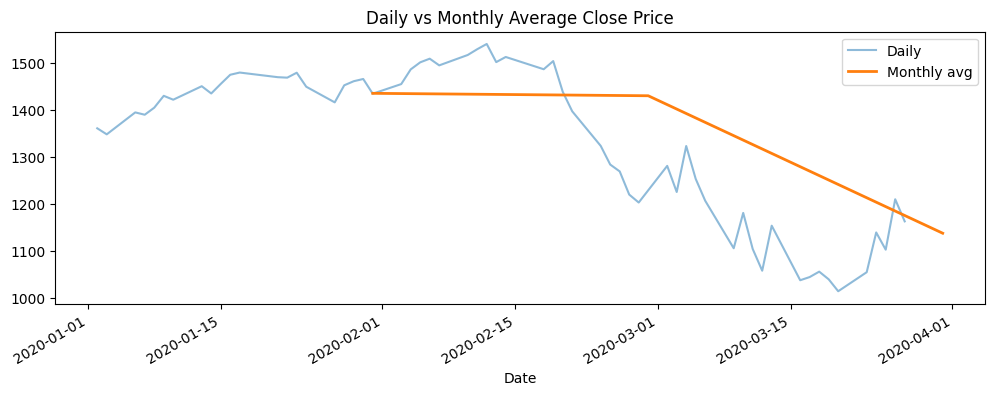

In [28]:
df['Close'].plot(label='Daily', alpha=0.5, figsize=(12, 4))
df_monthly['Close'].plot(label='Monthly avg', linewidth=2)
plt.title('Daily vs Monthly Average Close Price')
plt.legend()
plt.show()

---
# 📌 Topic 9 — Resampling: Upsampling + ffill / bfill

**Upsampling** = coarser → finer (Months → Days)

New rows that didn't exist start as `NaN`. Fill them with:
- **`ffill()`** — carry last known value forward
- **`bfill()`** — pull next known value backward

In [29]:
print('Monthly data:')
print(df_monthly['Close'])

Monthly data:
Date
2020-01-31   1,435.05
2020-02-29   1,429.86
2020-03-31   1,137.57
Freq: ME, Name: Close, dtype: float64


In [30]:
# Upsample without filling — NaN everywhere except original rows
df_monthly['Close'].resample(rule='W').mean().head(10)

Date
2020-02-02   1,435.05
2020-02-09        NaN
2020-02-16        NaN
2020-02-23        NaN
2020-03-01   1,429.86
2020-03-08        NaN
2020-03-15        NaN
2020-03-22        NaN
2020-03-29        NaN
2020-04-05   1,137.57
Freq: W-SUN, Name: Close, dtype: float64

In [31]:
# Forward fill — carry each month's value forward
print('Forward fill:')
print(df_monthly['Close'].resample(rule='W').ffill())

Forward fill:
Date
2020-02-02   1,435.05
2020-02-09   1,435.05
2020-02-16   1,435.05
2020-02-23   1,435.05
2020-03-01   1,429.86
2020-03-08   1,429.86
2020-03-15   1,429.86
2020-03-22   1,429.86
2020-03-29   1,429.86
2020-04-05   1,137.57
Freq: W-SUN, Name: Close, dtype: float64


In [32]:
# Backward fill — pull next month's value back
print('Backward fill:')
print(df_monthly['Close'].resample(rule='W').bfill())

Backward fill:
Date
2020-02-02   1,429.86
2020-02-09   1,429.86
2020-02-16   1,429.86
2020-02-23   1,429.86
2020-03-01   1,137.57
2020-03-08   1,137.57
2020-03-15   1,137.57
2020-03-22   1,137.57
2020-03-29   1,137.57
2020-04-05        NaN
Freq: W-SUN, Name: Close, dtype: float64


---
# 📌 Topic 10 — Interpolation

Instead of copying a flat value (ffill/bfill), **interpolation** estimates missing values by drawing a curve through the known points.

- **Linear** — straight line
- **Quadratic** — slightly curved
- **Cubic** — smoothest curve

The chart below shows the difference visually.

In [33]:
df_interp = pd.DataFrame()

# Upsample monthly → daily by reindexing (creates NaN gaps between known points)
daily_index = pd.date_range(start=df_monthly.index.min(), end=df_monthly.index.max(), freq='D')
close_daily = df_monthly['Close'].reindex(daily_index)

# Linear — fills gaps with a straight line between known points
df_interp['Linear']    = close_daily.interpolate(method='linear')

# Quadratic — fills gaps with a smooth curve (degree 2)
df_interp['Quadratic'] = close_daily.interpolate(method='quadratic')

# Cubic — fills gaps with a smoother curve (degree 3)
# Using numpy polyfit: works with any number of points, no scipy needed
import warnings
x_known = np.where(close_daily.notna())[0]
y_known = close_daily.dropna().values
x_all   = np.arange(len(close_daily))
with warnings.catch_warnings():
    warnings.simplefilter('ignore', np.exceptions.RankWarning)
    coeffs = np.polyfit(x_known, y_known, deg=3)
df_interp['Cubic'] = np.polyval(coeffs, x_all)

df_interp.head(10)

,Linear,Quadratic,Cubic
2020-01-31,"1,435.05","1,435.05","1,435.05"
2020-02-01,"1,434.87","1,439.18","1,437.03"
2020-02-02,"1,434.69","1,443.01","1,438.92"
2020-02-03,"1,434.51","1,446.53","1,440.73"
2020-02-04,"1,434.33","1,449.75","1,442.43"
2020-02-05,"1,434.15","1,452.65","1,444.03"
2020-02-06,"1,433.97","1,455.25","1,445.51"
2020-02-07,"1,433.79","1,457.54","1,446.88"
2020-02-08,"1,433.62","1,459.52","1,448.10"
2020-02-09,"1,433.44","1,461.19","1,449.20"


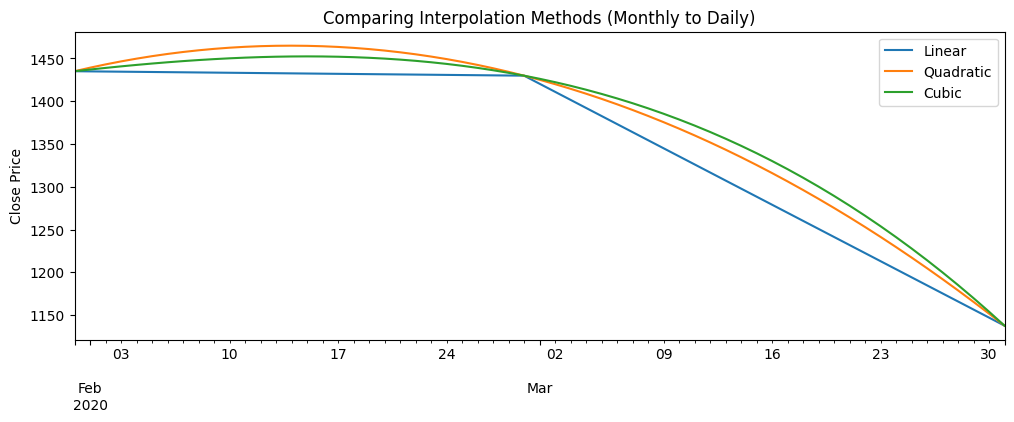

In [34]:
df_interp.plot(figsize=(12, 4))
plt.title('Comparing Interpolation Methods (Monthly to Daily)')
plt.ylabel('Close Price')
plt.show()

---
# 📌 Topic 11 — Rolling Windows

A **rolling window** slides a fixed-size window across the data one row at a time.

- `rolling(window=7)` → looks at the last 7 rows at each step
- First `window - 1` rows are `NaN` (not enough data yet)

**Most common use:** Moving averages in stock analysis

In [35]:
df['MA_7']  = df['Close'].rolling(window=7).mean()
df['MA_21'] = df['Close'].rolling(window=21).mean()

# Notice NaN at top until the window is full
df[['Close', 'MA_7', 'MA_21']].head(25)

,Close,MA_7,MA_21
Date,,,
2020-01-02,"1,360.66",NaN,NaN
2020-01-03,"1,347.83",NaN,NaN
2020-01-06,"1,394.48",NaN,NaN
2020-01-07,"1,389.52",NaN,NaN
2020-01-08,"1,404.50",NaN,NaN
2020-01-09,"1,429.73",NaN,NaN
2020-01-10,"1,421.47","1,392.60",NaN
2020-01-13,"1,450.16","1,405.38",NaN
2020-01-14,"1,434.73","1,417.80",NaN


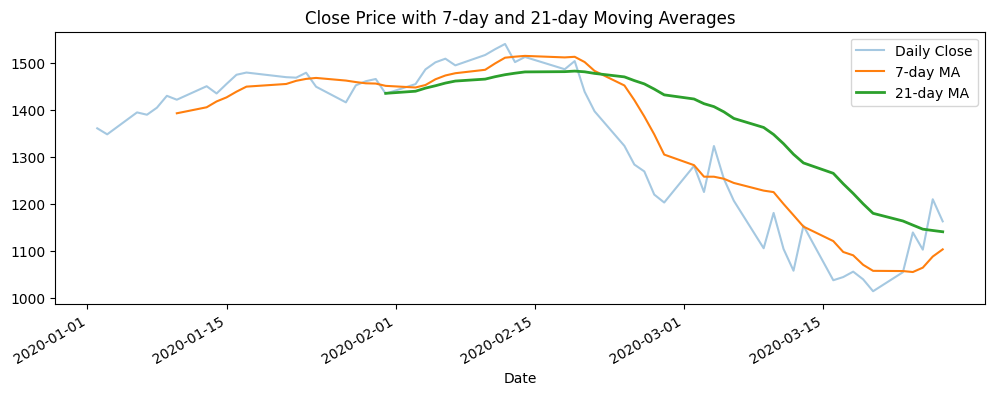

In [36]:
df['Close'].plot(label='Daily Close', alpha=0.4, figsize=(12, 4))
df['MA_7'].plot(label='7-day MA')
df['MA_21'].plot(label='21-day MA', linewidth=2)
plt.title('Close Price with 7-day and 21-day Moving Averages')
plt.legend()
plt.show()

---
# 📌 Topic 12 — Expanding Windows

An **expanding window** grows from the very first row to the current row.

- At row 1 → window has 1 value
- At row N → window has N values

Think of it as the **"running average since the beginning"**.

Useful for: cumulative averages, running totals, all-time highs.

In [ ]:
df['Expanding Mean'] = df['Close'].expanding().mean()

df[['Close', 'Expanding Mean']].head(10)

In [ ]:
df['Close'].plot(label='Daily Close', alpha=0.4, figsize=(12, 4))
df['MA_7'].plot(label='7-day Rolling Mean')
df['Expanding Mean'].plot(label='Expanding Mean', linewidth=2, linestyle='--')
plt.title('Rolling Window vs Expanding Window')
plt.legend()
plt.show()

---
# 📌 Topic 13 — Aggregation with .agg()

`.agg()` is a more flexible way to apply aggregation after resampling.

- Pass a string → `agg('mean')`
- Pass a list → `agg(['mean', 'max', 'min'])`
- Chain with column selection + date filter for powerful queries
- Use `.transpose()` to flip rows and columns

In [ ]:
# Option 1: direct .mean()
df['Close'].resample(rule='ME').mean()

In [ ]:
# Option 2: same result with .agg()
df['Close'].resample(rule='ME').agg('mean')

In [ ]:
# Store function name in a variable
func = 'mean'
df['Close'].resample(rule='ME').agg(func)

In [ ]:
# Multiple aggregation functions at once
funcs = ['mean', 'max', 'min']
df['Close'].resample(rule='ME').agg(funcs)

In [ ]:
# Most powerful form: columns + date filter + resample + multi-agg
funcs   = ['mean', 'max', 'min']
cols    = ['High', 'Low']
from_dt = '2020-01'
to_dt   = '2020-02'
freq    = 'W'

result = df[from_dt:to_dt][cols].resample(rule=freq).agg(funcs)
result

In [ ]:
# Transpose — sometimes easier to read
result.transpose()

---
# ✅ Summary

| # | Topic | Key function(s) |
|---|-------|-----------------|
| 1 | Loading time series data | `pd.read_csv(..., parse_dates=True)` |
| 2 | Date format pitfalls | Always check `dtype` of index |
| 3 | DatetimeIndex & sorting | `.sort_index()` |
| 4 | Date slicing | `df['2020-01':'2020-03']` |
| 5 | Date ranges & frequencies | `pd.date_range()` + offset aliases |
| 6 | Reindexing | `.reindex(labels=date_range)` |
| 7 | Shifting | `.shift(n)` |
| 8 | Downsampling | `.resample().mean()` |
| 9 | Upsampling + fill | `.resample().ffill()` / `.bfill()` |
| 10 | Interpolation | `.resample().interpolate(method=...)` |
| 11 | Rolling windows | `.rolling(window=n).mean()` |
| 12 | Expanding windows | `.expanding().mean()` |
| 13 | Aggregation | `.resample().agg([...])` |

---
🎉 **End of Lesson**